# 23CSE301 Machine Learning — Capstone Project
## Classification Track — Machine Predictive Maintenance

**Track owner:** _(team member name — see `docs/team_contributions.md`)_
**Review:** Part A → Review 1 · Part B → Review 2
**Dataset:** Machine Predictive Maintenance Classification — `predictive_maintenance.csv`
**Source:** https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

---

### How this notebook is organised
Every pipeline step calls the shared implementation in `src/`, which is the same
code that `scripts/run_all.py` executes. That keeps the notebook and the scripts
from drifting apart and means no result shown here is computed twice in two
different ways.

**On AI assistance:** code scaffolding in this project was generated with an AI
assistant (see `README.md` § AI-Assistance Disclosure). Every cell marked
**✍️ TEAM TO COMPLETE** must be written by the team. Those cells are empty on
purpose.

## 0. Environment

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # project root on the path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loading as dl, preprocessing as pp
from src import feature_engineering as fe, evaluation as ev, plotting as pl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("default")      # warnings stay visible on purpose

print("random_state =", config.RANDOM_STATE, "| test_size =", config.TEST_SIZE,
      "| cv folds =", config.CV_FOLDS)

random_state = 42 | test_size = 0.2 | cv folds = 5


In [2]:
from src import classification_models as cm
TARGET = "Target"
CLS = ["No Failure", "Failure"]
NUM = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
CAT = ['Type']

## 1. Data loading, audit and leakage exclusions  *(Rubric A1)*

**Target leakage, explicitly handled.** `Failure Type` is *not* a predictor: it
is a second recording of the same event as `Target`. A model given it would
score near-perfectly and learn nothing. `UDI` and `Product ID` are row
identifiers. All three are dropped.

In [3]:
raw = dl.load_raw("classification")
summary = dl.audit_summary(raw, "classification")
for k, v in summary.items(): print(f"  {k}: {v}")

[load_raw] classification: predictive_maintenance.csv -> shape (10000, 10) (expected (10000, 10))
  track: classification
  shape: (10000, 10)
  n_duplicate_rows: 0
  total_missing_cells: 0
  columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']
  target: Target
  target_present: True
  target_distribution: {0: 9661, 1: 339}


In [4]:
pd.crosstab(raw["Failure Type"], raw["Target"])

Target,0,1
Failure Type,,
Heat Dissipation Failure,0,112
No Failure,9643,9
Overstrain Failure,0,78
Power Failure,0,95
Random Failures,18,0
Tool Wear Failure,0,45


The crosstab above is the evidence for the exclusion: `Failure Type` is
deterministic given `Target` apart from a small number of ambiguous rows.

In [5]:
dl.audit(raw, "classification", "raw")

,column,dtype,missing,missing_pct,n_unique,example
0,UDI,int64,0,0.0,10000,1
1,Product ID,str,0,0.0,10000,M14860
2,Type,str,0,0.0,3,M
3,Air temperature [K],float64,0,0.0,93,298.1
4,Process temperature [K],float64,0,0.0,82,308.6
5,Rotational speed [rpm],int64,0,0.0,941,1551
6,Torque [Nm],float64,0,0.0,577,42.8
7,Tool wear [min],int64,0,0.0,246,0
8,Target,int64,0,0.0,2,0
9,Failure Type,str,0,0.0,6,No Failure


In [6]:
df = dl.prepare("classification", raw)
print("\nprepared columns:", list(df.columns))
df.head()

[prepare] classification: raw (10000, 10) -> prepared (10000, 7) (7 columns kept)
  excluded: ['UDI', 'Product ID', 'Failure Type']

prepared columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type', 'Target']


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Target
0,298.1,308.6,1551,42.8,0,M,0
1,298.2,308.7,1408,46.3,3,L,0
2,298.1,308.5,1498,49.4,5,L,0
3,298.2,308.6,1433,39.5,7,L,0
4,298.2,308.7,1408,40.0,9,L,0


## 2. EDA  *(Rubric A2, A3)*
The target is binary and heavily imbalanced, so a raw feature-vs-target scatter
would collapse onto two horizontal lines. Jitter plus a companion box plot is
used instead.

In [7]:
p = pl.distribution_grid(df[NUM + CAT], "Predictive Maintenance - input feature distributions",
                         "nb_clf_feature_distributions", "classification")

[fig] results/figures/classification/nb_clf_feature_distributions.png


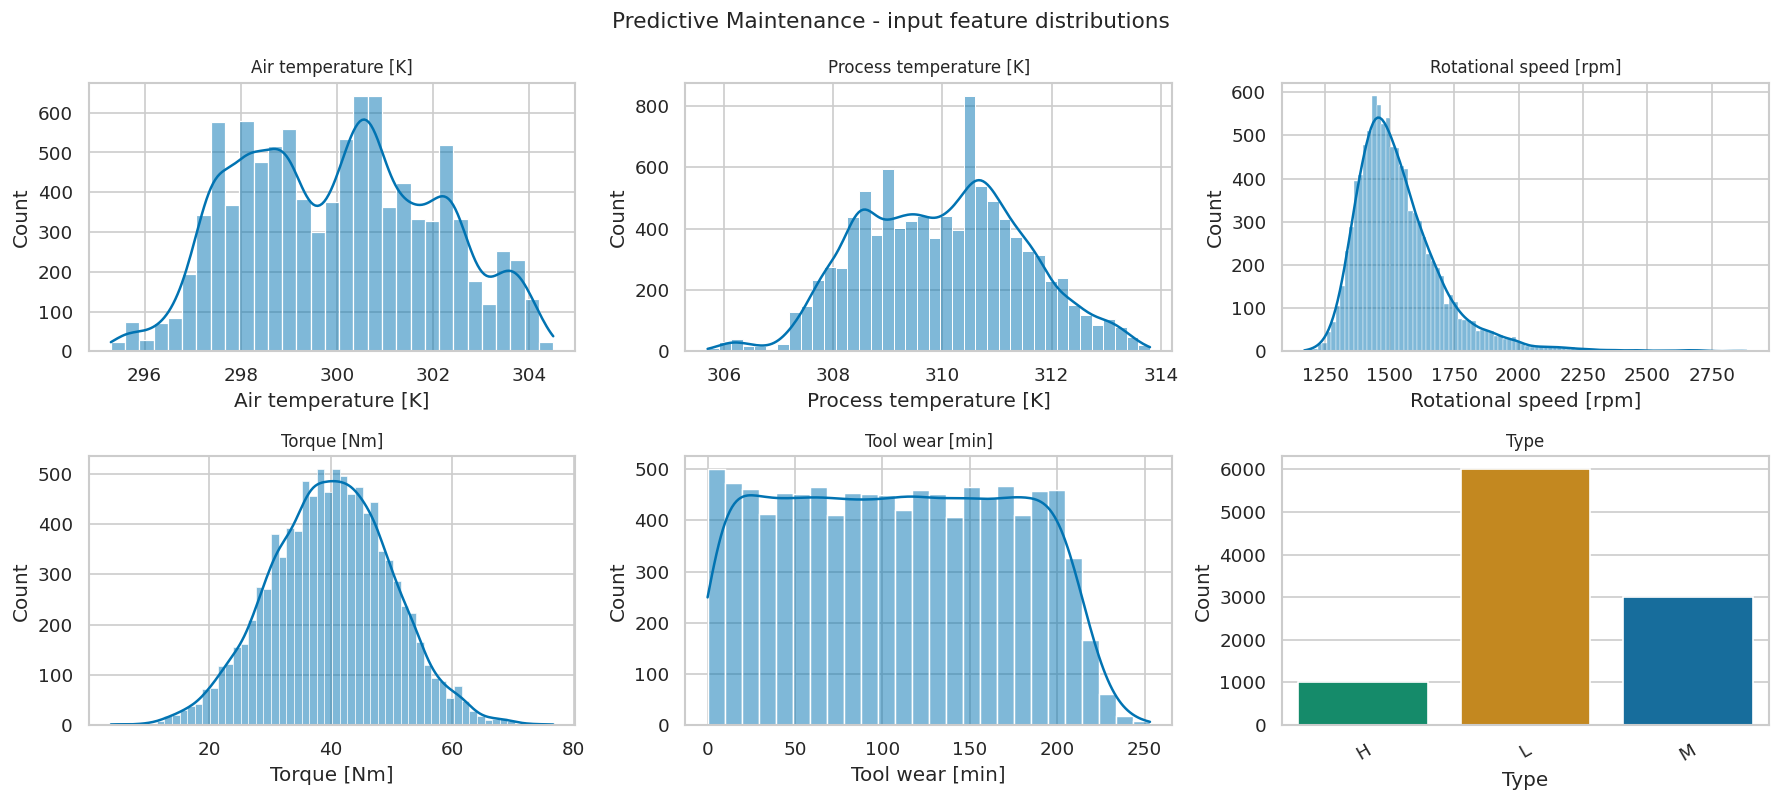

In [8]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Feature distributions
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which features look approximately normal and which are skewed or bounded?
> 2. Air and process temperature: what does their shape suggest about how this synthetic data was generated?
> 3. Does the Type category split the machines evenly?
>
> ---
>
> *(your written observation here)*

In [9]:
p = pl.correlation_heatmap(df, "Predictive Maintenance - correlation heatmap (numeric)",
                           "nb_clf_correlation_heatmap", "classification")

[fig] results/figures/classification/nb_clf_correlation_heatmap.png


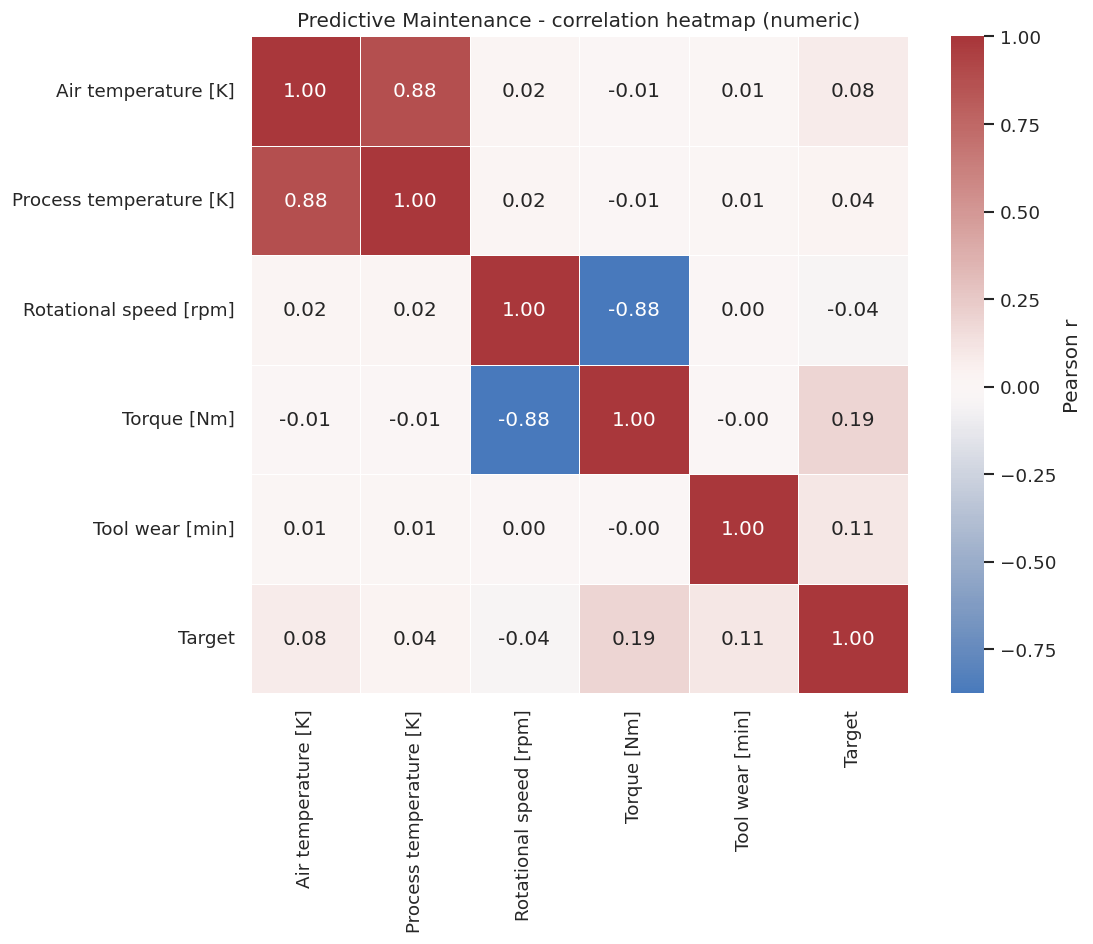

In [10]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Correlation structure
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Two pairs of features are strongly related. Which, and why physically?
> 2. Does any single feature correlate strongly with Target on its own? What does that imply about whether failure is a single-variable phenomenon?
>
> ---
>
> *(your written observation here)*

In [11]:
p = pl.target_distribution(df[TARGET], "Target distribution - machine failure",
                           "nb_clf_target_distribution", "classification",
                           discrete=True, class_names={0: CLS[0], 1: CLS[1]})

[fig] results/figures/classification/nb_clf_target_distribution.png


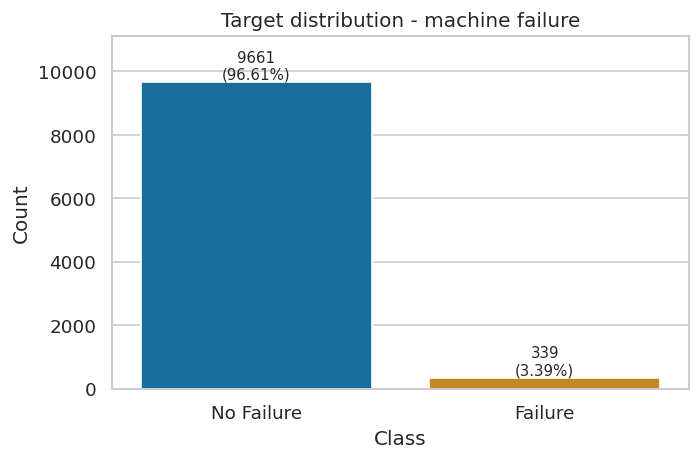

In [12]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Class imbalance
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. What fraction of rows are failures?
> 2. What accuracy would a model get by predicting 'No Failure' every single time?
> 3. Which metric should therefore lead your model comparison, and why not accuracy?
>
> ---
>
> *(your written observation here)*

In [13]:
p = pl.feature_target_scatter(df, ["Torque [Nm]", "Rotational speed [rpm]"], TARGET,
                              "nb_clf_feature_target_scatter", "classification", jitter=0.08,
                              title="Feature-target relationships (target jittered for readability)")

[fig] results/figures/classification/nb_clf_feature_target_scatter.png


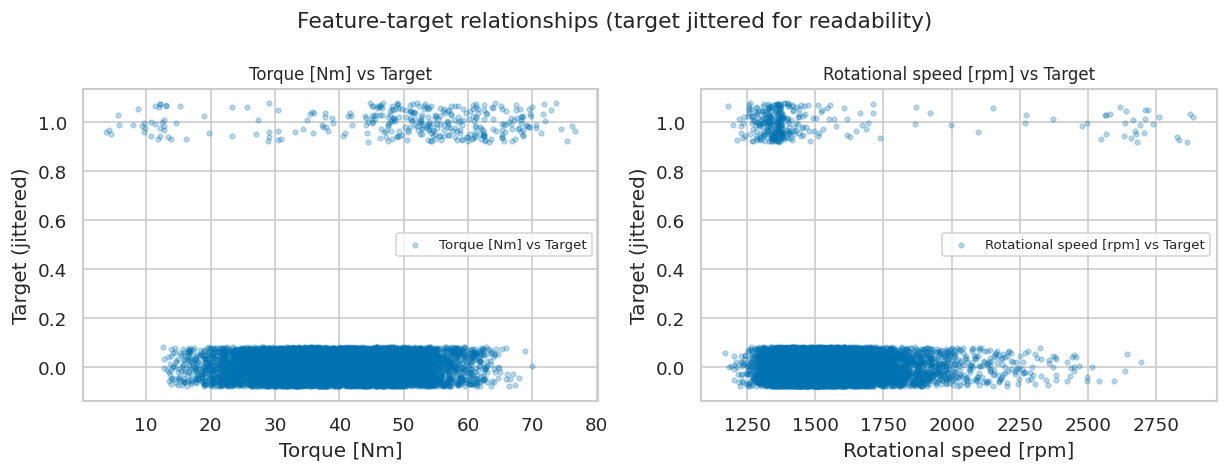

In [14]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [15]:
p = pl.grouped_box(df, ["Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]"], TARGET,
                   "nb_clf_feature_by_class", "classification",
                   class_names={0: CLS[0], 1: CLS[1]})

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: 

[fig] results/figures/classification/nb_clf_feature_by_class.png


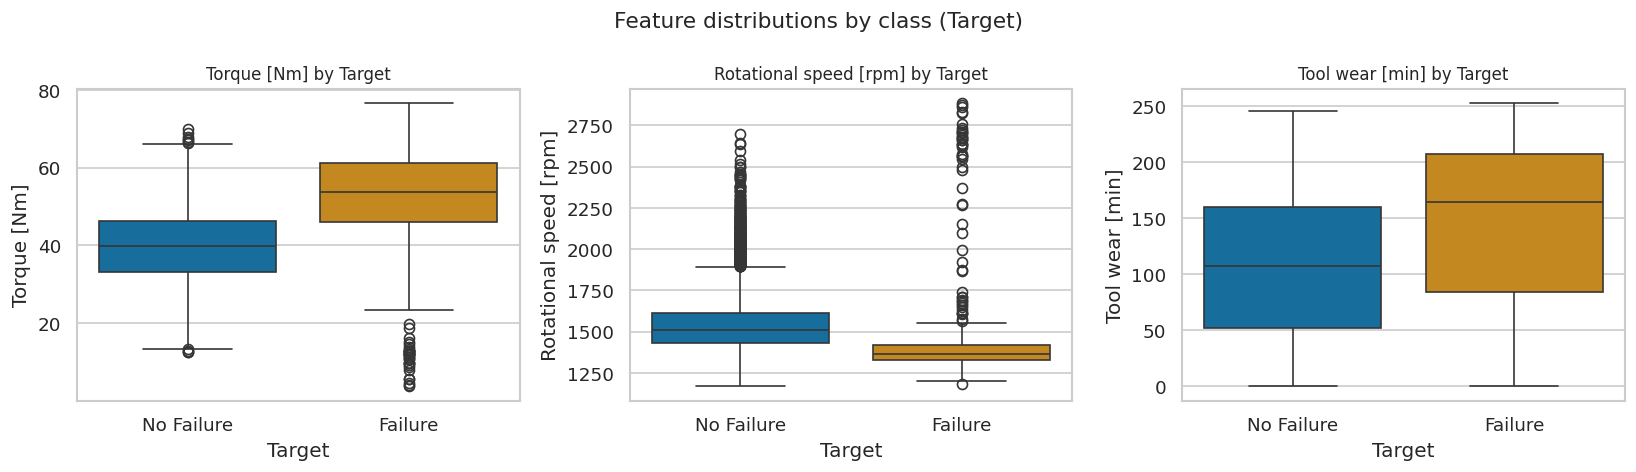

In [16]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Feature–target relationships
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. In which region of torque and rotational speed do failures concentrate?
> 2. Do the box plots separate the two classes for any single feature, or is failure an interaction between features?
> 3. What does that suggest about linear vs tree-based models here?
>
> ---
>
> *(your written observation here)*

## 3. Split, baseline and feature engineering  *(Rubric B1, B2, B3)*
Stratified 80:20 — with a 3.4 % positive class, an unstratified split could give
the folds very different failure rates.

In [17]:
X_train, X_test, y_train, y_test = pp.split_supervised(df, TARGET, stratify=True)
print(pp.check_no_row_leakage(X_train, X_test))
base = ev.majority_class_baseline(y_train, y_test)
base

[split] train=(8000, 6) test=(2000, 6) stratify=target
{'test_rows': 2000, 'test_rows_also_in_train': 0, 'pct': 0.0}


{'majority_class': 0,
 'baseline_accuracy': 0.966,
 'baseline_f1_weighted': 0.949293997965412,
 'test_class_counts': {0: 1932, 1: 68}}

> **Read the baseline before reading any model score.** Any model below must be
> compared against this number, not against zero.

In [18]:
fe.status("classification")

{'track': 'classification',
 'state': 'AWAITING TEAM INPUT',
 'rubric_B3': 'INCOMPLETE',
 'detail': 'No engineered feature registered; baseline pipeline executed.'}

> ### ✍️ TEAM TO COMPLETE — Engineered feature (Q-CF1) — required for rubric B3
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which physically meaningful quantity could you derive from the existing columns?
> 2. State your justification BEFORE measuring it.
> 3. After registering it and re-running, did recall on the failure class improve? Report honestly.
>
> ---
>
> *(your written observation here)*

## 4. Part A — the five Review 1 algorithms  *(Rubric D1, D2)*

**Metric conventions, stated once and used everywhere:**
* Precision and Recall are **binary**, positive class = **failure (`Target == 1`)**
* F1 is **weighted**, as the rubric mandates
* ROC-AUC uses `predict_proba` / `decision_function` — never hard labels

In [19]:
part_a = cm.build_part_a(NUM, CAT)
ta, fa, cma = ev.evaluate_classifiers(part_a, X_train, y_train, X_test, y_test)
ta

  A1. Logistic Regression            acc=0.9675 F1w=0.9560 rec(fail)=0.1029 AUC=0.8994
  A2. K-Nearest Neighbors            acc=0.9740 F1w=0.9679 rec(fail)=0.2941 AUC=0.8291


  A3. Gaussian Naive Bayes           acc=0.9580 F1w=0.9506 rec(fail)=0.1176 AUC=0.8468


  A4. Decision Tree Classifier       acc=0.9755 F1w=0.9714 rec(fail)=0.3824 AUC=0.9219


  A5. Support Vector Classifier      acc=0.9720 F1w=0.9635 rec(fail)=0.2059 AUC=0.9468


,Model,Accuracy,Precision_failure,Recall_failure,F1_weighted,F1_failure,ROC_AUC,AUC_source,Fit_seconds
Rank,,,,,,,,,
1,A4. Decision Tree Classifier,0.9755,0.787879,0.382353,0.971365,0.514851,0.921854,predict_proba,0.026
2,A2. K-Nearest Neighbors,0.9740,0.833333,0.294118,0.967929,0.434783,0.829086,predict_proba,0.020
3,A5. Support Vector Classifier,0.9720,0.875000,0.205882,0.963519,0.333333,0.946817,predict_proba,0.800
4,A1. Logistic Regression,0.9675,0.636364,0.102941,0.956012,0.177215,0.899388,predict_proba,0.021
5,A3. Gaussian Naive Bayes,0.9580,0.250000,0.117647,0.950634,0.160000,0.846814,predict_proba,0.014


In [20]:
p = pl.confusion_grid(cma, CLS, "Part A confusion matrices (held-out test set)",
                      "nb_clf_confusion_partA", "classification")

[fig] results/figures/classification/nb_clf_confusion_partA.png


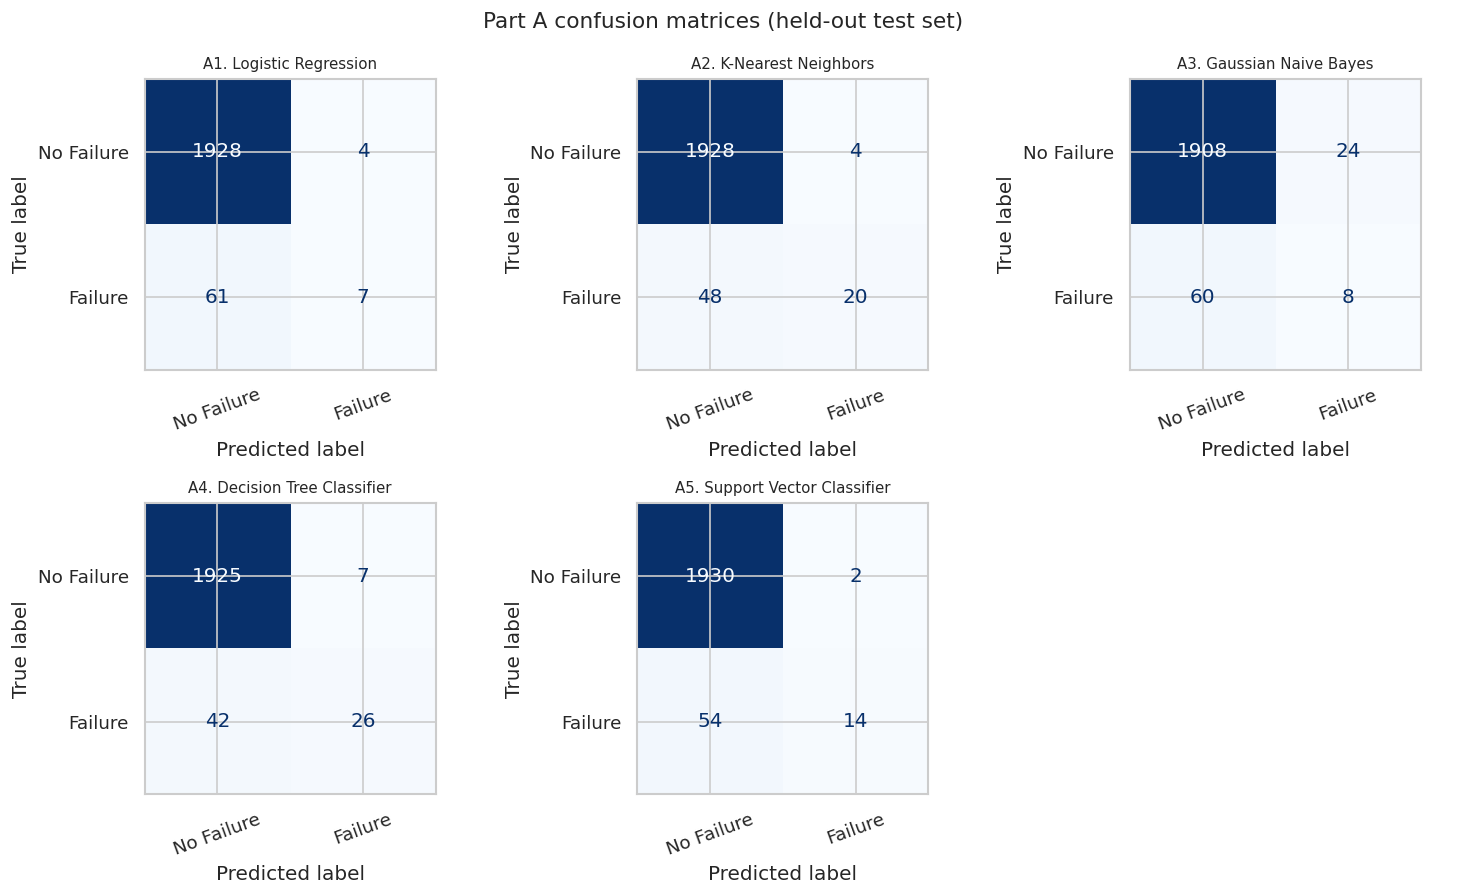

In [21]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Part A comparison (Review 1 deliverable)
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Rank the five models on weighted F1, then on failure recall. Does the ranking change?
> 2. Look at the confusion matrices: which models achieve high accuracy mainly by rarely predicting failure?
> 3. In a maintenance setting, which error is more expensive — a missed failure or a false alarm? Which model does your answer favour?
>
> ---
>
> *(your written observation here)*

## 5. Part B — the five Review 2 algorithms  *(Review 2, Rubric A1)*
Same dataset, same split, same preprocessing as Part A.

In [22]:
part_b = cm.build_part_b(NUM, CAT)
tb, fb, cmb = ev.evaluate_classifiers(part_b, X_train, y_train, X_test, y_test)
tb

  B6. Random Forest Classifier       acc=0.9815 F1w=0.9791 rec(fail)=0.5147 AUC=0.9709


  B7. AdaBoost Classifier            acc=0.9725 F1w=0.9667 rec(fail)=0.2941 AUC=0.9492


  B8. Gradient Boosting Classifier   acc=0.9860 F1w=0.9855 rec(fail)=0.7206 AUC=0.9673


  B9. Bagging (Decision Tree base)   acc=0.9865 F1w=0.9859 rec(fail)=0.7206 AUC=0.9598


  B10. MLP Classifier                acc=0.9810 F1w=0.9807 rec(fail)=0.6912 AUC=0.9789


,Model,Accuracy,Precision_failure,Recall_failure,F1_weighted,F1_failure,ROC_AUC,AUC_source,Fit_seconds
Rank,,,,,,,,,
1,B9. Bagging (Decision Tree base),0.9865,0.859649,0.720588,0.985925,0.784000,0.959818,predict_proba,1.703
2,B8. Gradient Boosting Classifier,0.9860,0.844828,0.720588,0.985463,0.777778,0.967292,predict_proba,1.625
3,B10. MLP Classifier,0.9810,0.734375,0.691176,0.980722,0.712121,0.978900,predict_proba,3.028
4,B6. Random Forest Classifier,0.9815,0.897436,0.514706,0.979062,0.654206,0.970866,predict_proba,1.713
5,B7. AdaBoost Classifier,0.9725,0.740741,0.294118,0.966710,0.421053,0.949169,predict_proba,0.867


In [23]:
p = pl.confusion_grid(cmb, CLS, "Part B confusion matrices (held-out test set)",
                      "nb_clf_confusion_partB", "classification")

[fig] results/figures/classification/nb_clf_confusion_partB.png


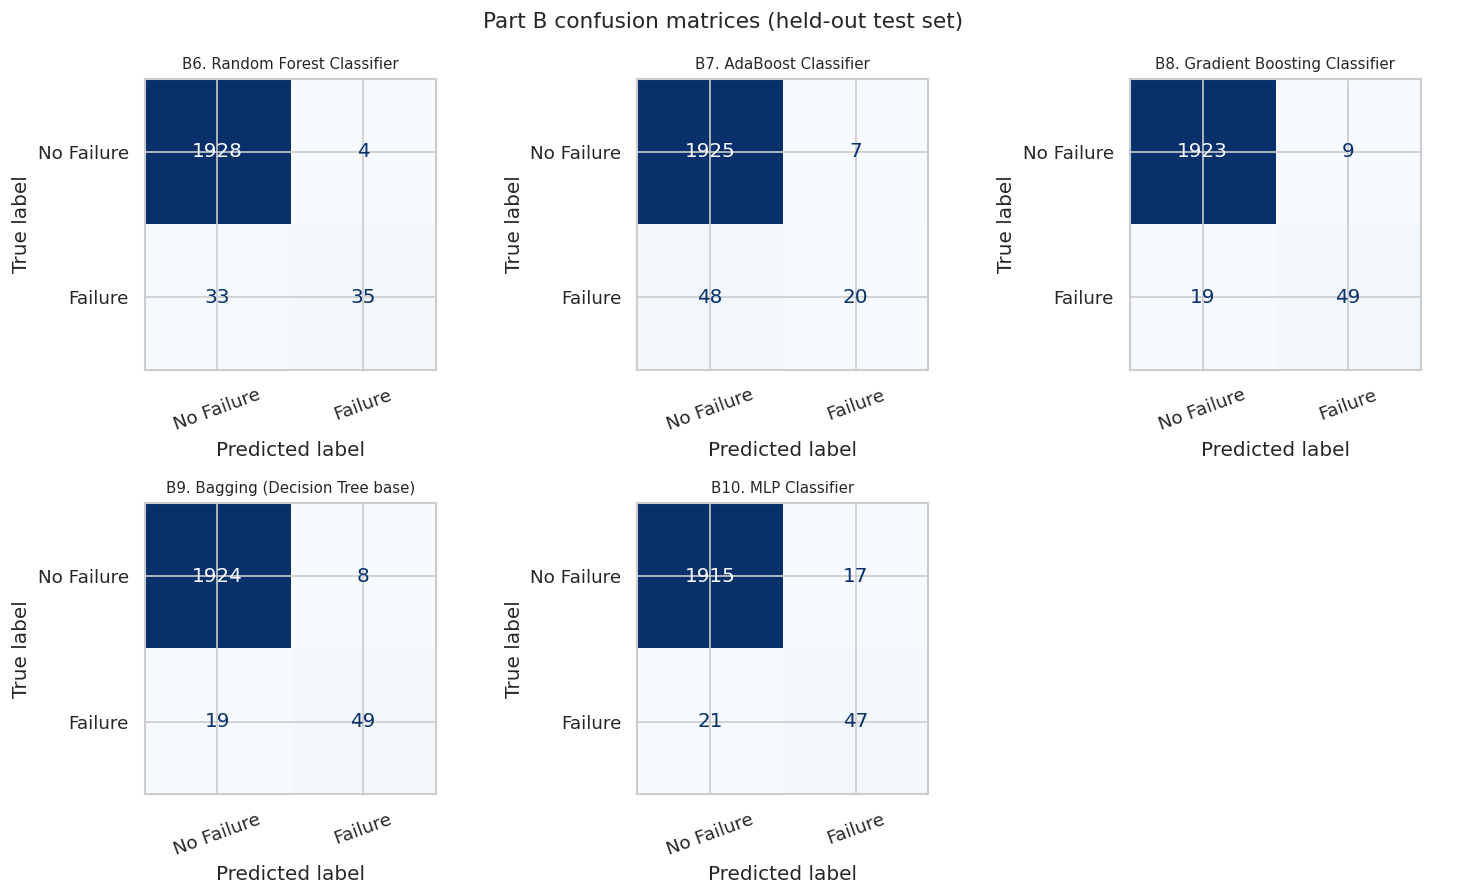

In [24]:
from IPython.display import Image, display
display(Image(filename=str(p)))

## 6. Consolidated 10-algorithm table  *(Review 2, Rubric A2 — deliverable D6)*

In [25]:
all_models = {**part_a, **part_b}
fitted = {**fa, **fb}
cms = {**cma, **cmb}
table = (pd.concat([ta.reset_index(drop=True), tb.reset_index(drop=True)])
         .sort_values("F1_weighted", ascending=False).reset_index(drop=True))
table.index = table.index + 1
table.index.name = "Rank"
table

,Model,Accuracy,Precision_failure,Recall_failure,F1_weighted,F1_failure,ROC_AUC,AUC_source,Fit_seconds
Rank,,,,,,,,,
1,B9. Bagging (Decision Tree base),0.9865,0.859649,0.720588,0.985925,0.784000,0.959818,predict_proba,1.703
2,B8. Gradient Boosting Classifier,0.9860,0.844828,0.720588,0.985463,0.777778,0.967292,predict_proba,1.625
3,B10. MLP Classifier,0.9810,0.734375,0.691176,0.980722,0.712121,0.978900,predict_proba,3.028
4,B6. Random Forest Classifier,0.9815,0.897436,0.514706,0.979062,0.654206,0.970866,predict_proba,1.713
5,A4. Decision Tree Classifier,0.9755,0.787879,0.382353,0.971365,0.514851,0.921854,predict_proba,0.026
6,A2. K-Nearest Neighbors,0.9740,0.833333,0.294118,0.967929,0.434783,0.829086,predict_proba,0.020
7,B7. AdaBoost Classifier,0.9725,0.740741,0.294118,0.966710,0.421053,0.949169,predict_proba,0.867
8,A5. Support Vector Classifier,0.9720,0.875000,0.205882,0.963519,0.333333,0.946817,predict_proba,0.800
9,A1. Logistic Regression,0.9675,0.636364,0.102941,0.956012,0.177215,0.899388,predict_proba,0.021


In [26]:
print("majority-class reference -> accuracy %.4f, weighted F1 %.4f"
      % (base["baseline_accuracy"], base["baseline_f1_weighted"]))
p = pl.model_comparison_bar(table, "F1_weighted", "Classifiers ranked by weighted F1",
                            "nb_clf_model_comparison", "classification")

majority-class reference -> accuracy 0.9660, weighted F1 0.9493
[fig] results/figures/classification/nb_clf_model_comparison.png


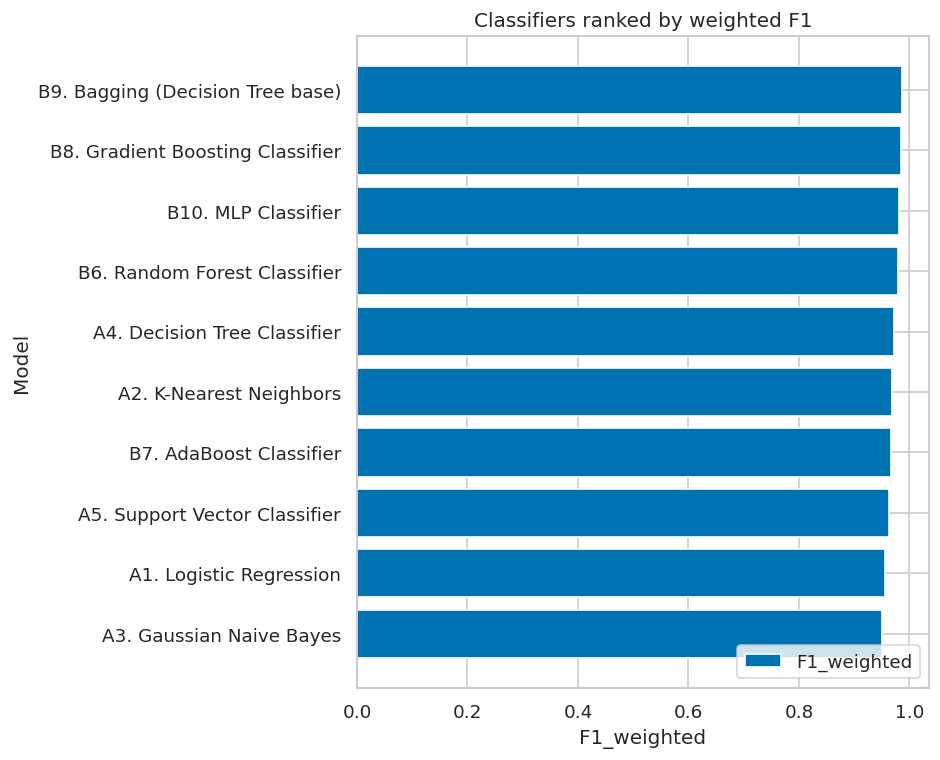

In [27]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [28]:
p = pl.roc_curves(fitted, X_test, y_test,
                  "ROC curves (probability / decision scores, not hard labels)",
                  "nb_clf_roc_curves", "classification")

[fig] results/figures/classification/nb_clf_roc_curves.png


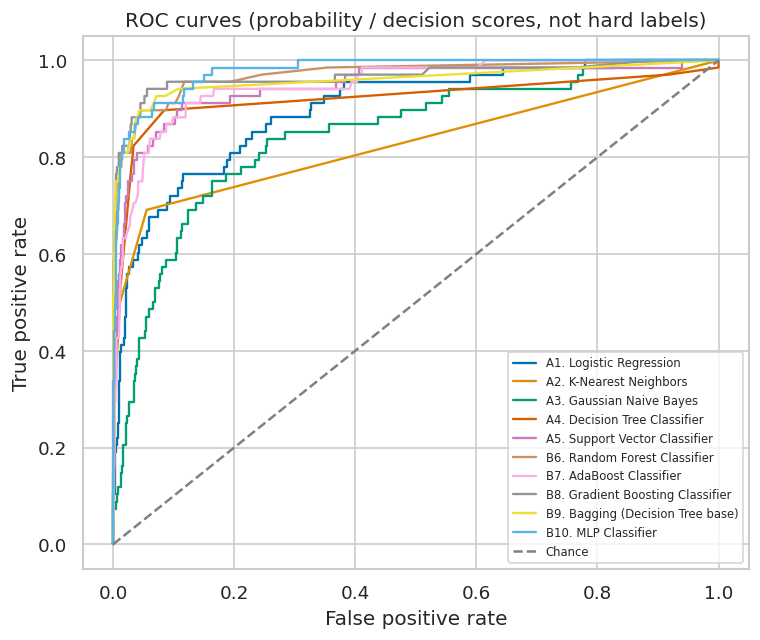

In [29]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Consolidated comparison
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which models beat the majority-class baseline on weighted F1 by a margin you consider meaningful?
> 2. Do the ROC-AUC ranking and the weighted-F1 ranking agree? Where they differ, explain why (hint: AUC is threshold-free).
> 3. Which family — linear, kernel, tree ensemble, neural — suits this problem best, and what about the data explains that?
>
> ---
>
> *(your written observation here)*

## 7. Cross-validation and tuning  *(Review 2, Rubric A3)*

In [30]:
cv_all = ev.cv_scores(all_models, X_train, y_train, scoring="f1_weighted")
cv_all.drop(columns="fold_scores")

  A1. Logistic Regression            f1_weighted CV = 0.9618 (+/- 0.0035)


  A2. K-Nearest Neighbors            f1_weighted CV = 0.9679 (+/- 0.0024)
  A3. Gaussian Naive Bayes           f1_weighted CV = 0.9553 (+/- 0.0034)


  A4. Decision Tree Classifier       f1_weighted CV = 0.9748 (+/- 0.0017)


  A5. Support Vector Classifier      f1_weighted CV = 0.9668 (+/- 0.0018)


  B6. Random Forest Classifier       f1_weighted CV = 0.9782 (+/- 0.0022)


  B7. AdaBoost Classifier            f1_weighted CV = 0.9680 (+/- 0.0021)


  B8. Gradient Boosting Classifier   f1_weighted CV = 0.9827 (+/- 0.0013)


  B9. Bagging (Decision Tree base)   f1_weighted CV = 0.9851 (+/- 0.0011)


  B10. MLP Classifier                f1_weighted CV = 0.9830 (+/- 0.0008)


,Model,scoring,folds,CV_mean,CV_std
0,A1. Logistic Regression,f1_weighted,5,0.961765,0.003476
1,A2. K-Nearest Neighbors,f1_weighted,5,0.967863,0.002429
2,A3. Gaussian Naive Bayes,f1_weighted,5,0.955302,0.003372
3,A4. Decision Tree Classifier,f1_weighted,5,0.974801,0.001737
4,A5. Support Vector Classifier,f1_weighted,5,0.966767,0.001767
5,B6. Random Forest Classifier,f1_weighted,5,0.978205,0.002217
6,B7. AdaBoost Classifier,f1_weighted,5,0.967967,0.002055
7,B8. Gradient Boosting Classifier,f1_weighted,5,0.982689,0.001342
8,B9. Bagging (Decision Tree base),f1_weighted,5,0.985124,0.001145
9,B10. MLP Classifier,f1_weighted,5,0.983006,0.000786


In [31]:
leaders = cv_all.sort_values("CV_mean", ascending=False)["Model"].head(2).tolist()
print("leaders (training CV):", leaders)
rows, tuned = {}, {}
for name in leaders:
    if name not in cm.PARAM_GRIDS: continue
    base_cv = float(cv_all.loc[cv_all["Model"] == name, "CV_mean"].iloc[0])
    before = table[table["Model"] == name].iloc[0]
    gs = cm.tune(name, all_models[name], X_train, y_train)
    score, _ = ev._scores_for_auc(gs.best_estimator_, X_test)
    after = ev.classification_metrics(y_test, gs.best_estimator_.predict(X_test), score)
    rows[name] = {"best_params": gs.best_params_,
                  "CV_F1w_before": round(base_cv, 5), "CV_F1w_after": round(gs.best_score_, 5),
                  "HeldOut_F1w_before": round(float(before["F1_weighted"]), 5),
                  "HeldOut_F1w_after": round(after["F1_weighted"], 5),
                  "Recall_fail_before": round(float(before["Recall_failure"]), 5),
                  "Recall_fail_after": round(after["Recall_failure"], 5)}
    tuned[name] = gs.best_estimator_
pd.DataFrame(rows).T

leaders (training CV): ['B9. Bagging (Decision Tree base)', 'B10. MLP Classifier']


  [tuned] B9. Bagging (Decision Tree base): best f1_weighted=0.9853 params={'model__max_samples': 0.8, 'model__n_estimators': 100}


  [tuned] B10. MLP Classifier: best f1_weighted=0.9830 params={'model__activation': 'relu', 'model__hidden_layer_sizes': (64, 32)}


,best_params,CV_F1w_before,CV_F1w_after,HeldOut_F1w_before,HeldOut_F1w_after,Recall_fail_before,Recall_fail_after
B9. Bagging (Decision Tree base),"{'model__max_samples': 0.8, 'model__n_estimato...",0.98512,0.98526,0.98593,0.98754,0.72059,0.75
B10. MLP Classifier,"{'model__activation': 'relu', 'model__hidden_l...",0.98301,0.98301,0.98072,0.98072,0.69118,0.69118


> ### ✍️ TEAM TO COMPLETE — Final model selection (Review 2, Rubric A3)
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which model do you select as final, and which metric drove the decision?
> 2. Did tuning improve at least one metric? Quote the before/after numbers — and if it did not, say so.
> 3. Does your chosen model trade failure recall for accuracy? Is that trade acceptable for the use case?
>
> ---
>
> *(your written observation here)*

## 8. Algorithm-specific requirements from the PDF
Odds/coefficients (#1), distance metrics (#2), conditional independence (#3),
tree visualisation (#4), feature importance (#6).

In [32]:
odds = cm.odds_table(fitted["A1. Logistic Regression"])
print("intercept:", round(odds.attrs["intercept"], 4), "|", odds.attrs["scale_note"])
odds

intercept: -4.9928 | numeric features are standardised; units are per 1 SD


,feature,coefficient_log_odds,odds_ratio
0,Torque [Nm],2.722502,15.218355
1,Rotational speed [rpm],2.021327,7.548334
2,Air temperature [K],1.427572,4.168567
3,Process temperature [K],-0.960367,0.382752
4,Tool wear [min],0.788159,2.199343
5,Type_L,0.376102,1.456596
6,Type_H,-0.284608,0.752309
7,Type_M,-0.105202,0.900142


In [33]:
cm.knn_distance_metric_comparison(NUM, CAT, X_train, y_train, X_test, y_test)

,distance_metric,Accuracy,Precision_failure,Recall_failure,F1_weighted,ROC_AUC
0,euclidean,0.9740,0.833333,0.294118,0.967929,0.829086
1,manhattan,0.9735,0.826087,0.279412,0.967100,0.829756
2,chebyshev,0.9710,0.777778,0.205882,0.962755,0.804017


> ### ✍️ TEAM TO COMPLETE — Odds ratios, distance metrics, and the Naive Bayes assumption
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Pick the largest odds ratio and state what a one-standard-deviation increase does to the odds of failure.
> 2. Did the KNN distance metric change performance materially? Why might that be, given the feature scales?
> 3. Gaussian NB assumes features are conditionally independent given the class. Using your correlation heatmap, name a pair that violates this. How did GaussianNB's score reflect that?
>
> ---
>
> *(your written observation here)*

In [34]:
dt = fitted["A4. Decision Tree Classifier"]
p = pl.decision_tree_figure(dt.named_steps["model"],
                            dt.named_steps["prep"].get_feature_names_out(),
                            CLS, "nb_clf_decision_tree", "classification", max_depth=3)

[fig] results/figures/classification/nb_clf_decision_tree.png


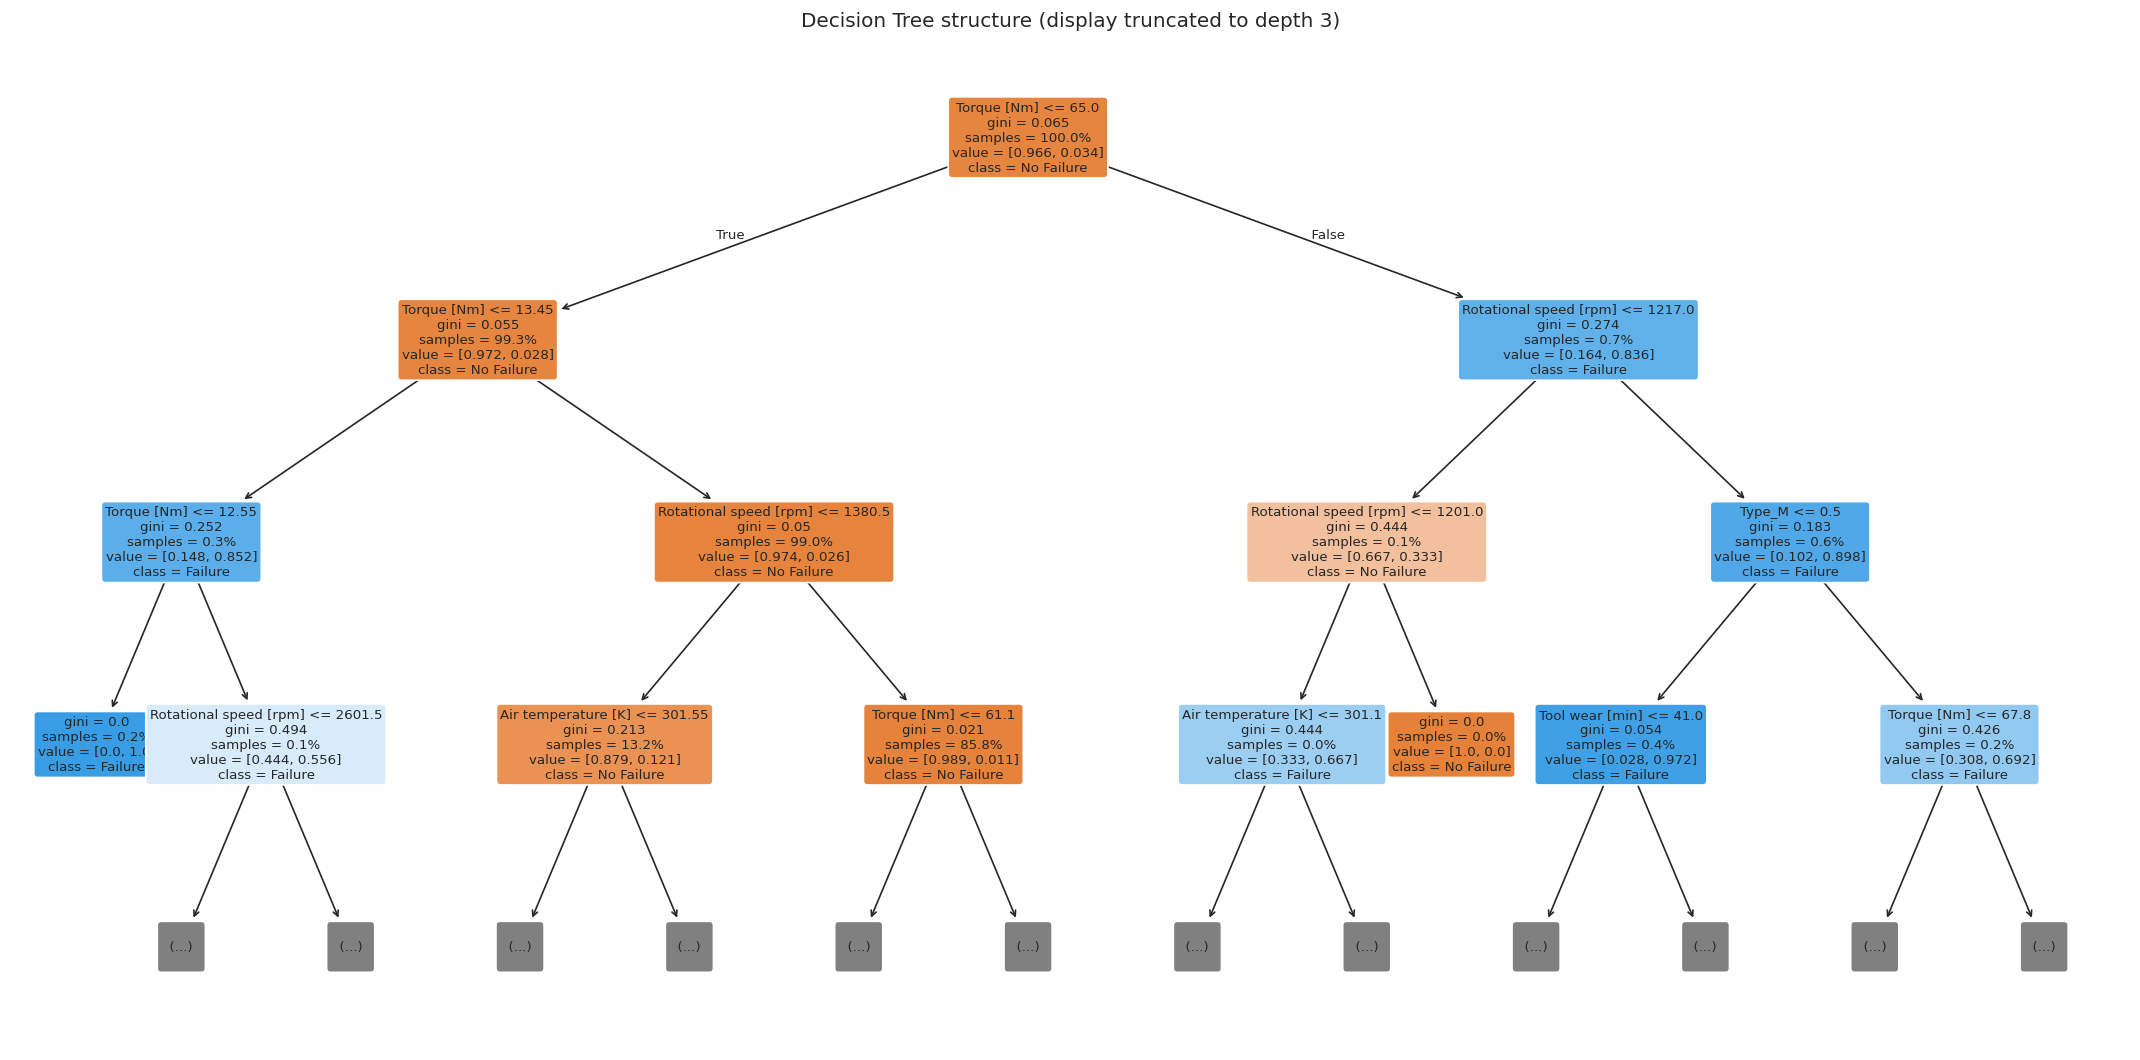

In [35]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [36]:
imp = cm.tree_importances(fitted["B6. Random Forest Classifier"])
p = pl.importance_plot(imp.values, imp.index, "Random Forest Classifier - feature importance",
                       "nb_clf_feature_importance", "classification", xlabel="Gini importance")
imp

[fig] results/figures/classification/nb_clf_feature_importance.png


Torque [Nm]                0.318358
Rotational speed [rpm]     0.235510
Tool wear [min]            0.166774
Air temperature [K]        0.130262
Process temperature [K]    0.124577
Type_L                     0.010774
Type_M                     0.008575
Type_H                     0.005170
dtype: float64

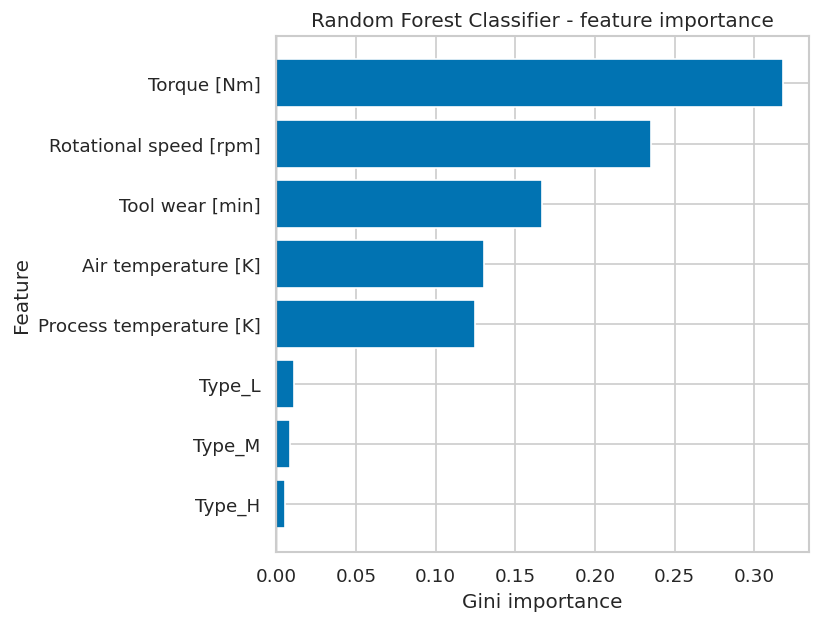

In [37]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Tree structure and importance
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Read the top two splits of the tree. What physical rule has it learned?
> 2. Do the Random Forest importances agree with those splits and with the logistic coefficients?
>
> ---
>
> *(your written observation here)*

## 9. Classification track conclusion

> ### ✍️ TEAM TO COMPLETE — Classification conclusion
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Summarise the whole track: problem → data → method → result → conclusion.
> 2. What is the single most important caveat a reader should keep in mind (imbalance? synthetic data? threshold choice?).
> 3. If this were deployed on a real production line, what would you monitor?
>
> ---
>
> *(your written observation here)*